In [1]:
import requests
import subprocess
import sys
import os
from urllib.request import urlretrieve
from zipfile import ZipFile

# Import the third-party libraries with shorthand notations
import requests
import pandas as pd
import numpy as np
import altair as alt
from vega_datasets import data
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.neighbors import BallTree
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFECV
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from scipy.stats import t
from preprocessing import get_unsup_df

Standard library os is available.
Standard library zipfile is available.
Standard library urllib is available.
Standard library csv is available.
Standard library math is available.


In [2]:
# UNSUPERVISED LEARNING
#StandardScaler so we can do PCA

df_unsup = get_unsup_df()

df_unsup = df_unsup.rename(columns={'data_value': 'AvgYearlyHDMort100k',
                        'yearly_avg': 'AvgYearlyCovidRate'}) #rename for clarity
df_features = df_unsup.drop(columns=['State Abbr.']) #drop states for PCA
scaler = StandardScaler()

df_scaled = pd.DataFrame(scaler.fit_transform(df_features), columns=df_features.columns)
#df_scaled = pd.concat([df_unsup['State Abbr.'], df_scaled], axis=1)
df_scaled.head()

c:\Dev\Pre-Existing-Factors\preprocessing.py:98: DtypeWarning: Columns (19,35) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(url, dtype=column_types)


,General Health,Exercise in Past 30 Days,Smoking,Shortness of Breath,Hours of Sleeping,BMI Category,Years Since Last Checkup,Cigarettes per Day,Drinks in Last 30 Days,Data_Value,AvgYearlyCovidRate
0,0.369883,0.541723,0.326813,-0.461917,0.316238,-0.178407,2.490940,0.059918,0.560993,-0.822369,-0.774868
1,-1.793435,-1.666695,0.759579,-0.784514,-0.350441,1.341446,-1.427182,-0.018017,-2.003308,2.118641,-0.168784
2,-2.224180,-2.268827,1.013090,-0.717353,0.292156,0.732940,-1.007102,1.531296,-1.169134,1.790534,-0.400267
3,-0.376401,-0.068246,-0.425345,0.211660,0.716825,-0.420804,0.707724,-0.095463,-0.140974,-0.750685,0.284873
4,0.359852,0.997991,-1.139709,0.080148,-0.182403,-1.337115,1.198726,-1.809212,0.699506,-0.636186,4.201528


In [3]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

df_pca_input = df_scaled
pca = PCA(n_components=0.95) #finding the features that explain 95% of the variance
df_pca = pca.fit_transform(df_pca_input)

df_pca = pd.DataFrame(df_pca, columns=[f'PC{i + 1}' for i in range(df_pca.shape[1])])
df_pca = pd.concat([df_unsup['State Abbr.'], df_pca], axis=1) #add back state names

explained_variance = pca.explained_variance_ratio_
df_pca.head()
#explained_variance

,State Abbr.,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
0,AK,1.140170,-1.649856,1.493889,-0.246830,-0.294442,-0.411247,1.342310,0.470639
1,AL,-3.908878,0.004092,-0.553518,-0.738164,1.055976,-0.027951,-1.480394,-0.393026
2,AR,-4.191724,-0.581805,-0.683294,0.053953,0.334153,0.625136,-0.012610,-0.881151
3,AZ,0.651484,-0.303313,0.491968,0.385735,0.596896,0.554115,0.336260,0.137279
4,CA,2.514892,2.872691,2.991544,-0.140956,0.525487,1.845030,-0.517655,-0.026427


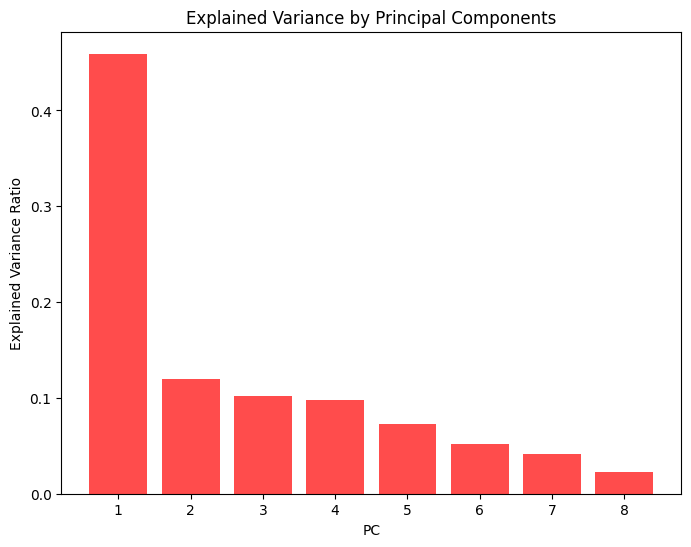

In [4]:
plt.figure(figsize=(8, 6))
plt.bar(range(1, len(explained_variance)+1), explained_variance, color = 'red',alpha=0.7)
plt.ylabel('Explained Variance Ratio')
plt.xlabel('PC')
plt.title('Explained Variance by Principal Components')
plt.show()

In [5]:
pca_components = pd.DataFrame(pca.components_,
                              columns=df_pca_input.columns,
                              index=[f'PC{i+1}' for i in range(pca.n_components_)])
pca_components

,General Health,Exercise in Past 30 Days,Smoking,Shortness of Breath,Hours of Sleeping,BMI Category,Years Since Last Checkup,Cigarettes per Day,Drinks in Last 30 Days,Data_Value,AvgYearlyCovidRate
PC1,0.413930,0.419788,-0.378315,0.147842,0.138531,-0.369827,0.152569,-0.310018,0.240940,-0.391345,-0.030118
PC2,-0.044082,-0.005049,-0.129131,0.291269,-0.586891,-0.123988,-0.334763,-0.050033,0.092002,0.008520,0.643116
PC3,-0.173654,0.040565,0.254038,-0.079564,0.042601,0.070889,0.728684,-0.327815,0.154581,0.135995,0.457886
PC4,0.005579,-0.083447,0.045561,0.711973,0.491297,0.305767,-0.018808,0.257397,0.220526,-0.062529,0.173230
PC5,-0.114178,0.014209,-0.277882,0.304383,0.077817,-0.098006,0.196740,-0.104226,-0.864046,0.020293,0.068393
PC6,-0.014896,-0.103260,-0.258609,-0.497484,0.476407,-0.151849,-0.138630,0.307451,-0.060680,-0.128778,0.539180
PC7,-0.086963,0.060938,0.066009,0.081052,-0.292922,-0.324428,0.429226,0.731449,0.027696,-0.245870,-0.079171
PC8,0.083007,0.027785,0.125776,-0.142914,-0.176606,0.575359,0.015719,-0.045734,-0.183959,-0.741767,0.086415


In [6]:
pca_components.loc['PC1'].sort_values(ascending=False)
#exercise and general health is correlated, mortality data value is negatively correlated

Exercise in Past 30 Days    0.419788
General Health              0.413930
Drinks in Last 30 Days      0.240940
Years Since Last Checkup    0.152569
Shortness of Breath         0.147842
Hours of Sleeping           0.138531
AvgYearlyCovidRate         -0.030118
Cigarettes per Day         -0.310018
BMI Category               -0.369827
Smoking                    -0.378315
Data_Value                 -0.391345
Name: PC1, dtype: float64

In [7]:
pca_components.loc['PC2'].sort_values(ascending=False)
# Covid average and shortness of breath are correlated! also hours of sleeping

AvgYearlyCovidRate          0.643116
Shortness of Breath         0.291269
Drinks in Last 30 Days      0.092002
Data_Value                  0.008520
Exercise in Past 30 Days   -0.005049
General Health             -0.044082
Cigarettes per Day         -0.050033
BMI Category               -0.123988
Smoking                    -0.129131
Years Since Last Checkup   -0.334763
Hours of Sleeping          -0.586891
Name: PC2, dtype: float64

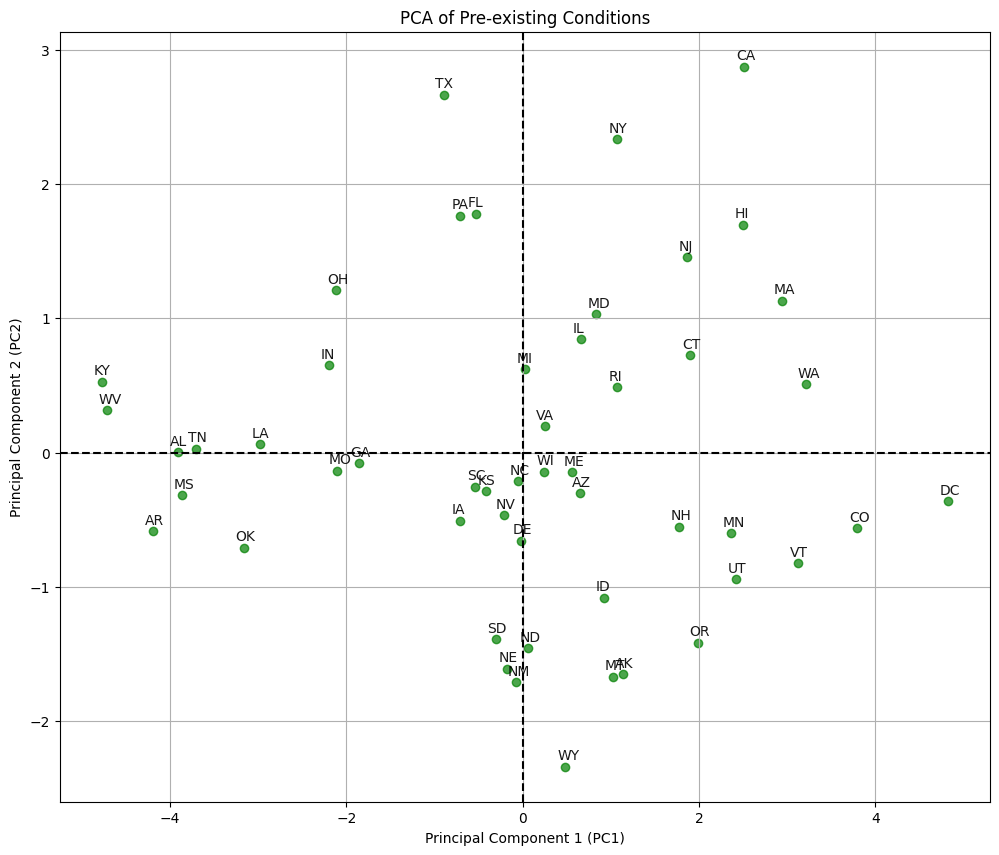

In [8]:
#visualizing the PCs

pc1 = df_pca['PC1']
pc2 = df_pca['PC2']

states = df_unsup['State Abbr.']

plt.figure(figsize=(12, 10))
plt.scatter(pc1, pc2, color = 'green', alpha=0.7)

for i, state in enumerate(df_unsup['State Abbr.']):
    plt.annotate(state, (pc1.iloc[i], pc2.iloc[i]), fontsize=10, alpha=0.9,
                 xytext=(-6, 5), textcoords='offset points') #state annotations

plt.title('PCA of Pre-existing Conditions')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')

#plt.gca().set_facecolor('grey')
plt.axhline(y=0, color='black', linewidth=1.5,linestyle='--')
plt.axvline(x=0, color='black', linewidth=1.5,linestyle='--')

plt.grid()
plt.show()

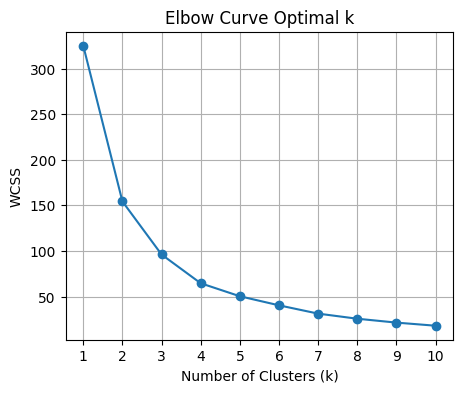

In [9]:
###K Means Clustering
from sklearn.cluster import KMeans

wcss = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_pca[['PC1', 'PC2']])
    wcss.append(kmeans.inertia_)

#elbow curve
plt.figure(figsize=(5, 4))
plt.plot(k_range, wcss, marker='o')
plt.title('Elbow Curve Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.xticks(k_range)
plt.grid()
plt.show()

In [10]:
#Optimal k seems to be 3 or 4
optimal_k = 4

kmeans = KMeans(n_clusters=optimal_k, random_state=42,n_init=10)
df_pca['KM_Cluster'] = kmeans.fit_predict(df_pca[['PC1', 'PC2']])
df_pca[['PC1', 'PC2', 'KM_Cluster']].head()

,PC1,PC2,KM_Cluster
0,1.140170,-1.649856,1
1,-3.908878,0.004092,0
2,-4.191724,-0.581805,0
3,0.651484,-0.303313,1
4,2.514892,2.872691,2


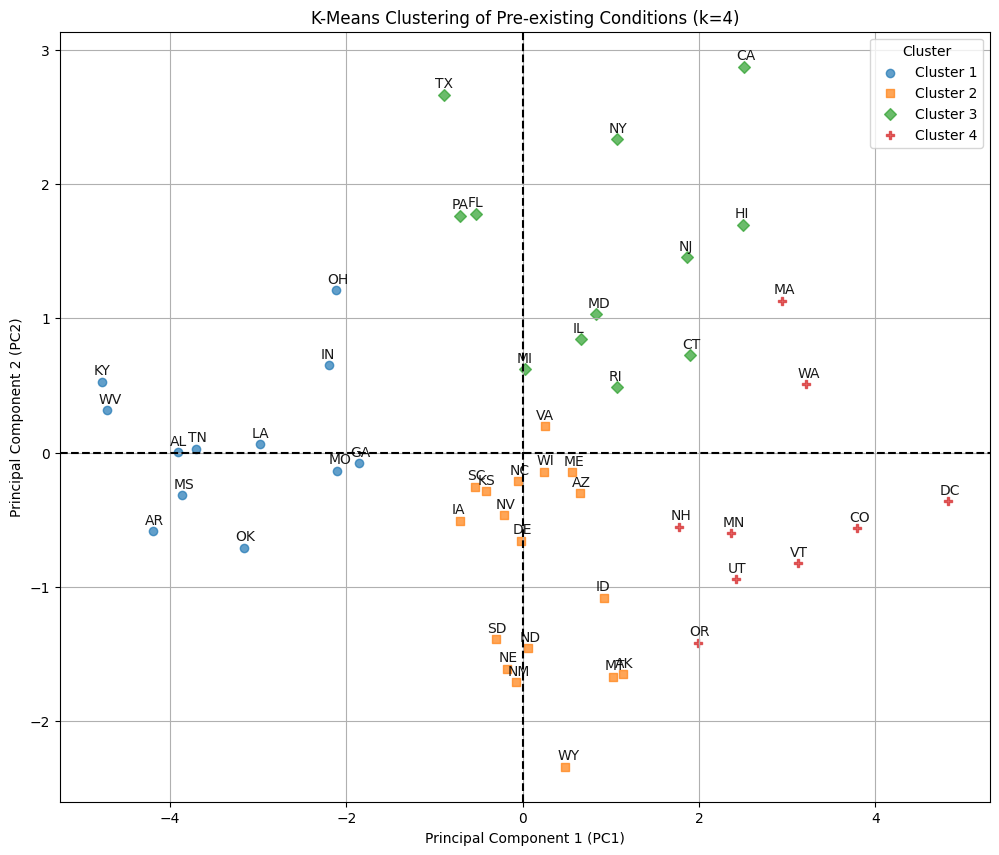

In [11]:
markers = ['o', 's', 'D', 'P', 'X']
plt.figure(figsize=(12, 10))

for cluster in range(optimal_k):
    cluster_data = df_pca[df_pca['KM_Cluster'] == cluster]
    plt.scatter(cluster_data['PC1'], cluster_data['PC2'],
                marker=markers[cluster % len(markers)],
                alpha=0.7, label=f'Cluster {cluster+1}')

for i, state in enumerate(df_unsup['State Abbr.']):
    plt.annotate(state, (pc1.iloc[i], pc2.iloc[i]), fontsize=10, alpha=0.9,
                 xytext=(-6, 5), textcoords='offset points')

plt.title(f'K-Means Clustering of Pre-existing Conditions (k={optimal_k})')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.axhline(y=0, color='black', linewidth=1.5, linestyle='--')
plt.axvline(x=0, color='black', linewidth=1.5, linestyle='--')
plt.grid()


plt.legend(title='Cluster', loc='upper right')
plt.show()

In [12]:
cluster_proportions = df_pca['KM_Cluster'].value_counts(normalize=True) * 100
print(cluster_proportions)

KM_Cluster
1    35.294118
0    23.529412
2    23.529412
3    17.647059
Name: proportion, dtype: float64


In [13]:
#KMEANS evaluation
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

silhouette_avg = silhouette_score(df_pca[['PC1', 'PC2']], df_pca['KM_Cluster'])
print(f'Silhouette Score for KMeans {silhouette_avg}')
X_kmeans = df_pca[['PC1', 'PC2']].values
dbi_kmeans = davies_bouldin_score(X_kmeans, df_pca['KM_Cluster'])
print(f"Davies-Bouldin for KMeans {dbi_kmeans}")
ch_index_kmeans = calinski_harabasz_score(X_kmeans, df_pca['KM_Cluster'])
print(f"Calinski-Harabasz for KMeans {ch_index_kmeans}")

Silhouette Score for KMeans 0.4413186139304351
Davies-Bouldin for KMeans 0.7706932463078732
Calinski-Harabasz for KMeans 63.22723656574757


In [14]:
#DBSCAN
from sklearn.cluster import DBSCAN

X = df_pca[['PC1', 'PC2']].values
scaler = StandardScaler()
X_normalized = scaler.fit_transform(X)

In [15]:
dbscan = DBSCAN(eps=0.5, min_samples=5)
clusters = dbscan.fit_predict(X_normalized)
df_pca['DBSCAN_Cluster'] = clusters

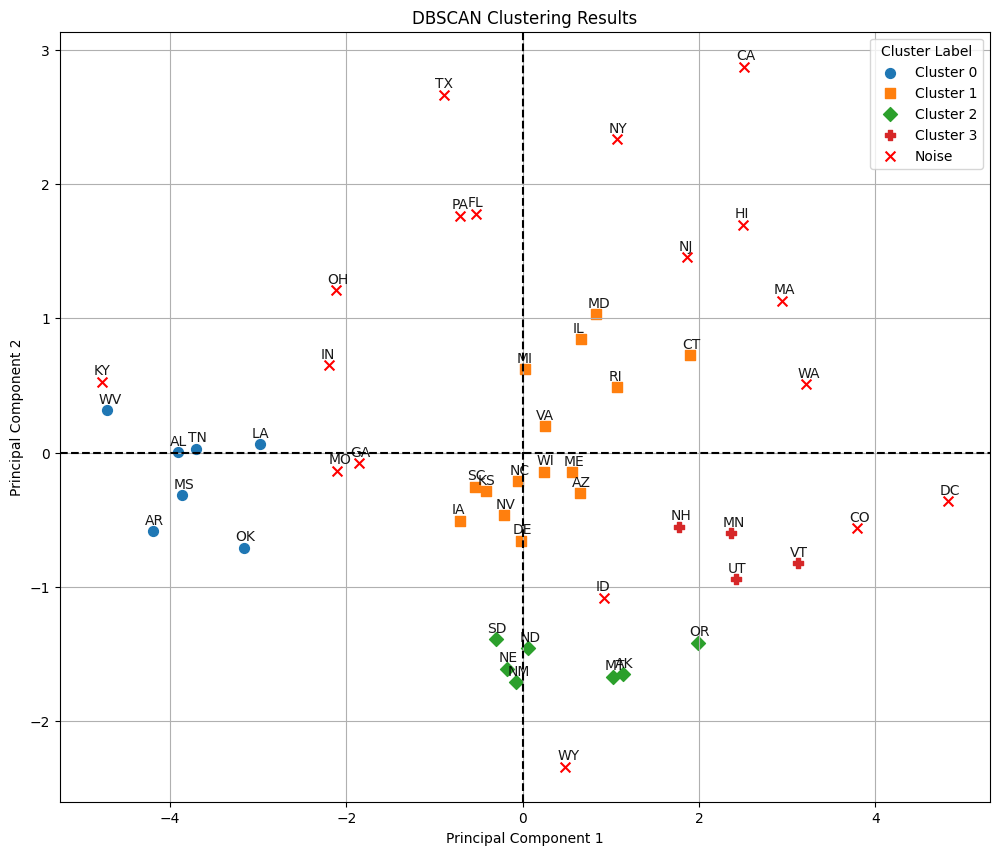

In [16]:
markers = ['o', 's', 'D', 'P', 'X']
noise_marker = 'x'
unique_clusters = set(clusters)

plt.figure(figsize=(12, 10))
for i, cluster in enumerate(unique_clusters):
    if cluster != -1:
        cluster_data = df_pca[df_pca['DBSCAN_Cluster'] == cluster]
        plt.scatter(cluster_data['PC1'], cluster_data['PC2'],
                    marker=markers[i % len(markers)],
                    s=50, label=f'Cluster {cluster}')

noise_data = df_pca[df_pca['DBSCAN_Cluster'] == -1]
plt.scatter(noise_data['PC1'], noise_data['PC2'],
            marker=noise_marker, color='red', s=50, label='Noise') #noise label

for i, state in enumerate(df_unsup['State Abbr.']):
    plt.annotate(state, (df_pca['PC1'].iloc[i], df_pca['PC2'].iloc[i]),
                 fontsize=10, alpha=0.9, xytext=(-6, 5), textcoords='offset points') #state annotations

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('DBSCAN Clustering Results')
plt.axhline(y=0, color='black', linewidth=1.5, linestyle='--')
plt.axvline(x=0, color='black', linewidth=1.5, linestyle='--')
plt.grid()

plt.legend(title='Cluster Label')
plt.show()

In [17]:
n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
n_noise = list(clusters).count(-1)

print(f'Number of clusters {n_clusters}')
print(f'Number of noise points {n_noise}')

Number of clusters 4
Number of noise points 18


In [18]:
numeric_columns = df_pca.select_dtypes(include=['number']).columns
cluster_summary = df_pca[numeric_columns].groupby(df_pca['DBSCAN_Cluster']).mean()
cluster_summary

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,KM_Cluster,DBSCAN_Cluster
DBSCAN_Cluster,,,,,,,,,,
-1,0.498026,0.780154,0.296005,-0.073114,0.084381,-0.009171,0.186877,-0.027494,1.555556,-1.0
0,-3.789206,-0.170342,-0.050018,-0.397260,0.231829,-0.171894,-0.264938,-0.377468,0.000000,0.0
1,0.282140,0.062970,-0.509303,0.093217,-0.224861,0.019324,-0.115783,0.163367,1.333333,1.0
2,0.520905,-1.554999,0.635674,0.321764,-0.408345,0.121310,0.038549,0.118616,1.285714,2.0
3,2.420385,-0.727484,-0.447031,0.111568,0.772417,0.057328,-0.010581,-0.035912,3.000000,3.0


In [19]:
#inverse transform from PCA data back to original feature space
df_reconstructed = pd.DataFrame(pca.inverse_transform(df_pca[pca_components.index]),
                                columns=df_unsup.drop(columns=['State Abbr.']).columns)
df_reconstructed['DBSCAN_Cluster'] = df_pca['DBSCAN_Cluster']
cluster_summary_original_features = df_reconstructed.groupby('DBSCAN_Cluster').mean()
cluster_summary_original_features

,General Health,Exercise in Past 30 Days,Smoking,Shortness of Breath,Hours of Sleeping,BMI Category,Years Since Last Checkup,Cigarettes per Day,Drinks in Last 30 Days,Data_Value,AvgYearlyCovidRate
DBSCAN_Cluster,,,,,,,,,,,
-1,0.091915,0.236005,-0.229486,0.274580,-0.459872,-0.365610,0.129539,-0.182950,0.159284,-0.166087,0.593256
0,-1.586688,-1.564269,1.339770,-0.700125,-0.541835,1.169613,-0.600279,0.843852,-1.151759,1.871447,-0.175617
1,0.251988,0.081975,-0.169612,0.056154,0.023001,0.030909,-0.444956,0.037548,0.175458,-0.284733,-0.166731
2,0.226883,0.212772,0.279442,-0.395870,1.163714,0.220943,0.978440,-0.106622,0.476378,-0.272144,-0.624250
3,1.021082,0.995689,-1.164888,0.471806,0.894881,-0.904137,0.423878,-0.607682,-0.192831,-0.983641,-0.644644


In [20]:
original_features = df_unsup.drop(columns=['State Abbr.'])
cluster_summary = original_features.groupby(df_pca['DBSCAN_Cluster']).mean()
cluster_summary
#very high Covid rates for the "noise" States, differences in shortness of breath and smoking between all the DBSCAN clusters

,General Health,Exercise in Past 30 Days,Smoking,Shortness of Breath,Hours of Sleeping,BMI Category,Years Since Last Checkup,Cigarettes per Day,Drinks in Last 30 Days,Data_Value,AvgYearlyCovidRate
DBSCAN_Cluster,,,,,,,,,,,
-1,3.432377,0.767853,0.513368,7670.333333,6.990388,1.985056,1.386409,5.654016,1.129802,319.165540,151.472019
0,3.223745,0.687873,0.638421,4201.571429,6.981807,2.117167,1.330607,6.624230,0.948117,447.482228,63.096505
1,3.439810,0.762863,0.499699,6813.333333,7.027589,2.028914,1.344088,5.894737,1.141362,314.365776,65.882964
2,3.423734,0.761532,0.550345,5343.142857,7.127411,2.030508,1.455044,5.657979,1.186753,305.522017,14.085418
3,3.548156,0.812409,0.419296,8193.500000,7.100441,1.957433,1.412327,5.363757,1.075765,278.481012,21.338288


In [21]:
#DBSCAN model evaluation
non_noise_indices = df_pca['DBSCAN_Cluster'] != -1
X_non_noise = X_normalized[non_noise_indices]
clusters_non_noise = clusters[non_noise_indices]

silhouette_avg_dbscan = silhouette_score(X_non_noise, clusters_non_noise)
print(f"Silhouette Score for DBSCAN {silhouette_avg_dbscan}")
dbi = davies_bouldin_score(X_non_noise, clusters_non_noise)
print(f"Davies-Bouldin Index for DBSCAN {dbi}")
#lower is better
ch_index = calinski_harabasz_score(X_non_noise, clusters_non_noise)
print(f"Calinski-Harabasz Index for DBSCAN {ch_index}")
#higher is better

Silhouette Score for DBSCAN 0.5315134116806237
Davies-Bouldin Index for DBSCAN 0.5742031260813656
Calinski-Harabasz Index for DBSCAN 49.97720833483014


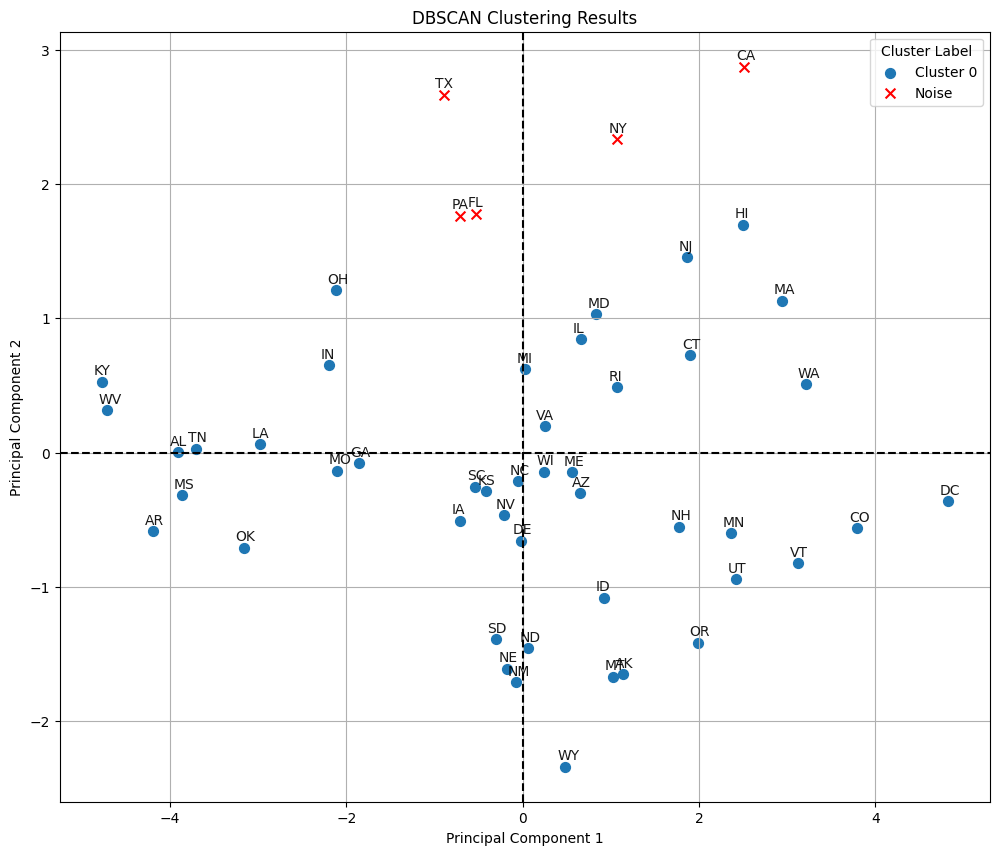

In [22]:
#tried optimizing the hyperparamters but 0.5 and min sample = 5 were the best results.

dbscan = DBSCAN(eps=0.7, min_samples=5)
clusters = dbscan.fit_predict(X_normalized)
df_pca['DBSCAN_Cluster'] = clusters
markers = ['o', 's', 'D', 'P', 'X']
noise_marker = 'x'

unique_clusters = set(clusters)

plt.figure(figsize=(12, 10))
for i, cluster in enumerate(unique_clusters):
    if cluster != -1:
        cluster_data = df_pca[df_pca['DBSCAN_Cluster'] == cluster]
        plt.scatter(cluster_data['PC1'], cluster_data['PC2'],
                    marker=markers[i % len(markers)],
                    s=50, label=f'Cluster {cluster}')

noise_data = df_pca[df_pca['DBSCAN_Cluster'] == -1]
plt.scatter(noise_data['PC1'], noise_data['PC2'],
            marker=noise_marker, color='red', s=50, label='Noise')

for i, state in enumerate(df_unsup['State Abbr.']):
    plt.annotate(state, (df_pca['PC1'].iloc[i], df_pca['PC2'].iloc[i]),
                 fontsize=10, alpha=0.9, xytext=(-6, 5), textcoords='offset points')

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('DBSCAN Clustering Results')
plt.axhline(y=0, color='black', linewidth=1.5, linestyle='--')
plt.axvline(x=0, color='black', linewidth=1.5, linestyle='--')
plt.grid()
plt.legend(title='Cluster Label')
plt.show()

In [23]:
#AGGLOMERATE CLUSTERING - HIERARCHAL

In [24]:
df_pca.head()
#print(df_pca.columns)

,State Abbr.,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,KM_Cluster,DBSCAN_Cluster
0,AK,1.140170,-1.649856,1.493889,-0.246830,-0.294442,-0.411247,1.342310,0.470639,1,0
1,AL,-3.908878,0.004092,-0.553518,-0.738164,1.055976,-0.027951,-1.480394,-0.393026,0,0
2,AR,-4.191724,-0.581805,-0.683294,0.053953,0.334153,0.625136,-0.012610,-0.881151,0,0
3,AZ,0.651484,-0.303313,0.491968,0.385735,0.596896,0.554115,0.336260,0.137279,1,0
4,CA,2.514892,2.872691,2.991544,-0.140956,0.525487,1.845030,-0.517655,-0.026427,2,-1


Silhouette Score 0.22850776017025565


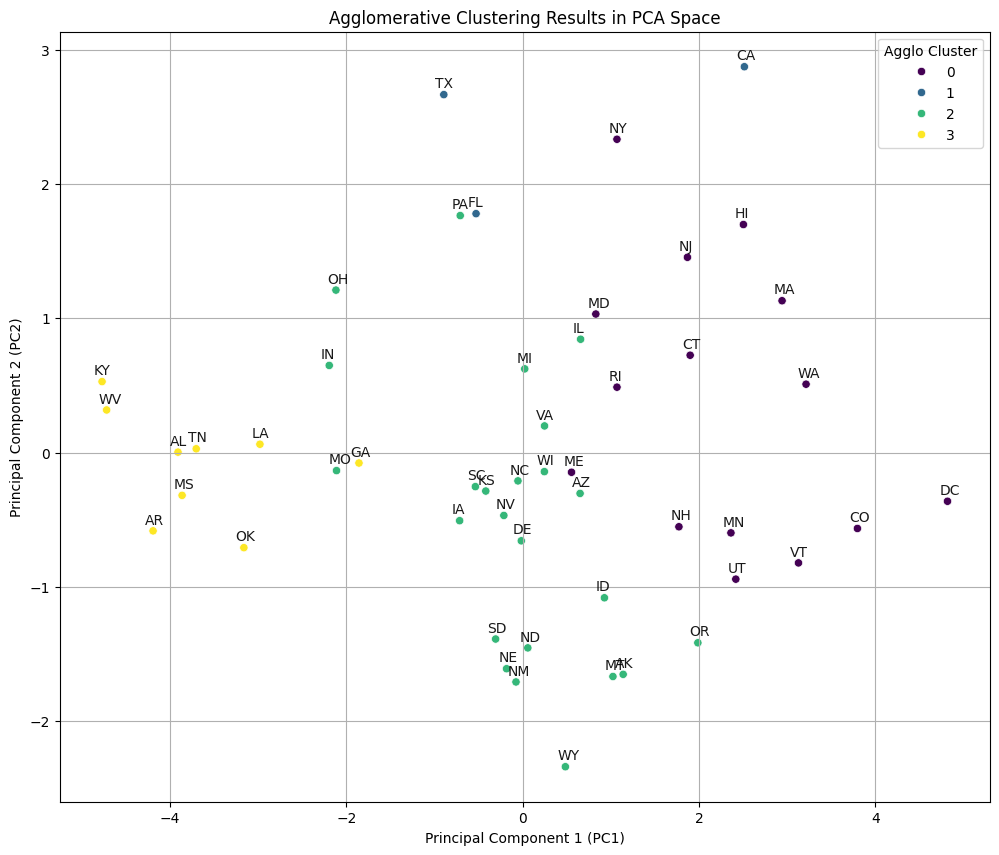

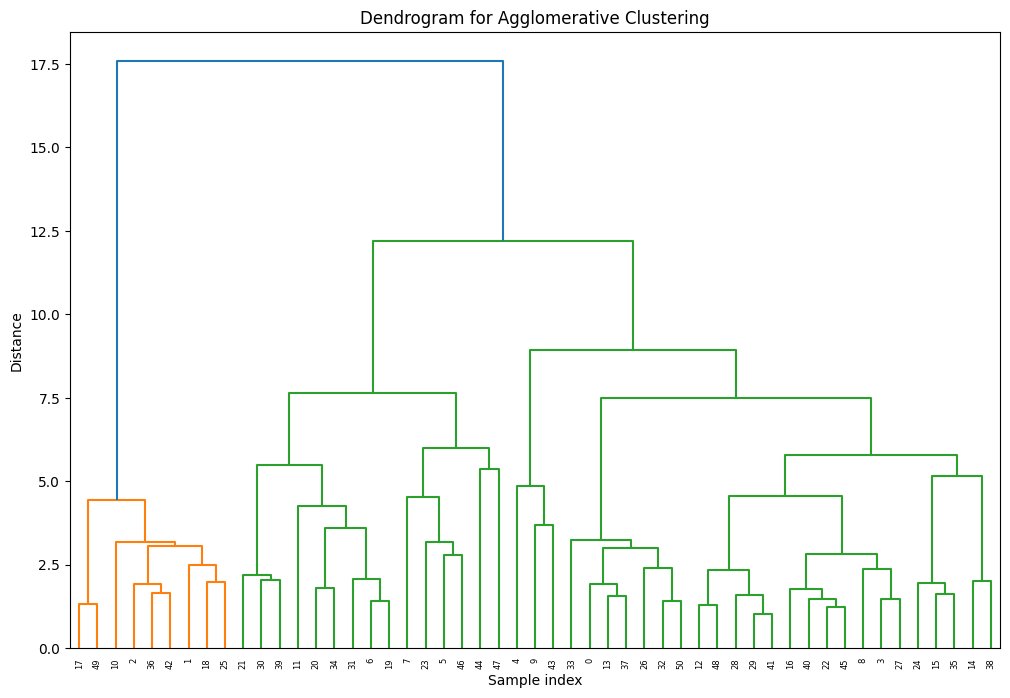

In [25]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
import seaborn as sns

agglo_model = AgglomerativeClustering(n_clusters=4, metric='euclidean', linkage='ward')
df_pca['Agglo_Cluster'] = agglo_model.fit_predict(df_pca.drop(columns=['State Abbr.', 'KM_Cluster', 'DBSCAN_Cluster']))

silhouette_avg = silhouette_score(df_pca.drop(columns=['State Abbr.', 'KM_Cluster', 'DBSCAN_Cluster', 'Agglo_Cluster']), df_pca['Agglo_Cluster'])
print(f"Silhouette Score {silhouette_avg}")

plt.figure(figsize=(12, 10))
sns.scatterplot(x='PC1', y='PC2', hue='Agglo_Cluster', data=df_pca, palette='viridis', legend='full')

for i, state in enumerate(df_pca['State Abbr.']):
    plt.annotate(state, (df_pca['PC1'].iloc[i], df_pca['PC2'].iloc[i]), fontsize=10, alpha=0.9,
                 xytext=(-6, 5), textcoords='offset points')

plt.title('Agglomerative Clustering Results in PCA Space')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.legend(title='Agglo Cluster')
plt.grid()
plt.show()

linkage_matrix = linkage(df_pca.drop(columns=['State Abbr.', 'KM_Cluster', 'DBSCAN_Cluster', 'Agglo_Cluster']), method='ward')
plt.figure(figsize=(12, 8))
dendrogram(linkage_matrix) #dendogram diagram
plt.title('Dendrogram for Agglomerative Clustering')
plt.xlabel('Sample index')
plt.ylabel('Distance')
plt.show()


In [26]:
#HYPERPARAMETER TUNING for Agglomerative

for k in range(2, 10):
    agglo_model = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = agglo_model.fit_predict(df_pca.drop(columns=['State Abbr.', 'KM_Cluster', 'DBSCAN_Cluster', 'Agglo_Cluster']))
    score = silhouette_score(df_pca.drop(columns=['State Abbr.', 'KM_Cluster', 'DBSCAN_Cluster', 'Agglo_Cluster']), labels)
    print(f" {k} clusters, Silhouette Score {score}")

 2 clusters, Silhouette Score 0.2954671170876893
 3 clusters, Silhouette Score 0.21315696381473986
 4 clusters, Silhouette Score 0.22850776017025565
 5 clusters, Silhouette Score 0.2180921345919941
 6 clusters, Silhouette Score 0.17964852602720485
 7 clusters, Silhouette Score 0.18201233496775088
 8 clusters, Silhouette Score 0.17274786076970047
 9 clusters, Silhouette Score 0.17991121465646998


In [27]:
for method in ['ward', 'complete', 'average', 'single']:
    agglo_model = AgglomerativeClustering(n_clusters=4, linkage=method)
    labels = agglo_model.fit_predict(df_pca.drop(columns=['State Abbr.', 'KM_Cluster', 'DBSCAN_Cluster', 'Agglo_Cluster']))
    score = silhouette_score(df_pca.drop(columns=['State Abbr.', 'KM_Cluster', 'DBSCAN_Cluster', 'Agglo_Cluster']), labels)
    print(f"Linkage {method}, Silhouette Score {score}")

Linkage ward, Silhouette Score 0.22850776017025565
Linkage complete, Silhouette Score 0.1862231951235244
Linkage average, Silhouette Score 0.19082257618747342
Linkage single, Silhouette Score 0.12788749129944013


In [28]:
for metric in ['euclidean', 'manhattan', 'cosine']:
    agglo_model = AgglomerativeClustering(n_clusters=4, metric=metric, linkage='average')
    labels = agglo_model.fit_predict(df_pca.drop(columns=['State Abbr.', 'KM_Cluster', 'DBSCAN_Cluster', 'Agglo_Cluster']))
    score1 = silhouette_score(df_pca.drop(columns=['State Abbr.', 'KM_Cluster', 'DBSCAN_Cluster', 'Agglo_Cluster']), labels)
    score2 = calinski_harabasz_score(df_pca.drop(columns=['State Abbr.', 'KM_Cluster', 'DBSCAN_Cluster', 'Agglo_Cluster']), labels)
    score3 = davies_bouldin_score(df_pca.drop(columns=['State Abbr.', 'KM_Cluster', 'DBSCAN_Cluster', 'Agglo_Cluster']), labels)
    print(f"Metric {metric}, Silhouette Score {score1}, Davies-Bouldin {score2}, Calinski-Harabasz {score}3")
#higher better
#lower better (does well!)

Metric euclidean, Silhouette Score 0.19082257618747342, Davies-Bouldin 3.3903054572115665, Calinski-Harabasz 0.127887491299440133
Metric manhattan, Silhouette Score 0.19082257618747342, Davies-Bouldin 3.3903054572115665, Calinski-Harabasz 0.127887491299440133
Metric cosine, Silhouette Score 0.16115834879779278, Davies-Bouldin 11.352712043627271, Calinski-Harabasz 0.127887491299440133


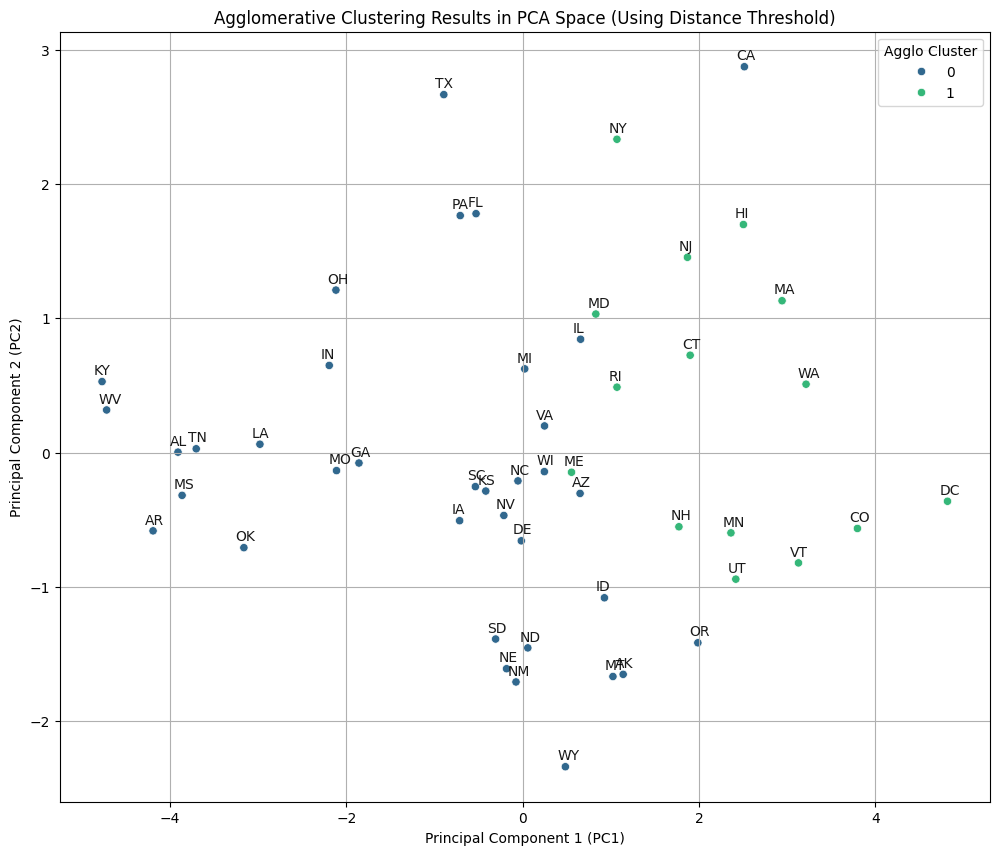

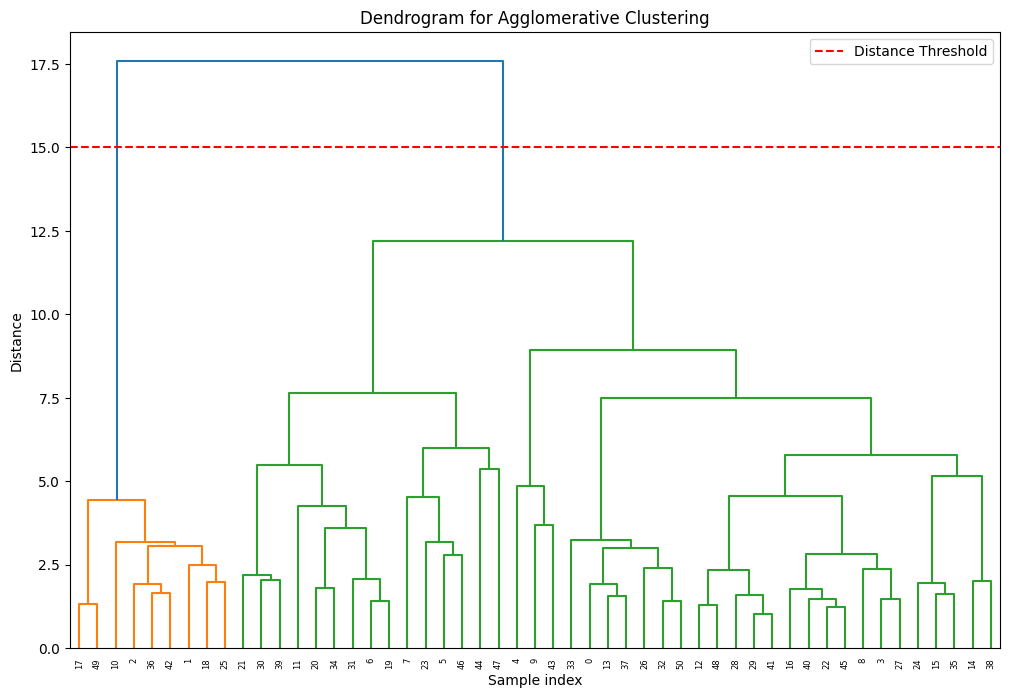

In [29]:
#TRYING TO IMPLEMENT A DISTANCE THRESHOLD FOR CUTOFF, tuning

agglo_model = AgglomerativeClustering(distance_threshold=15,  # Adjust
                                      n_clusters=None,  # Automatic determine number of clusters
                                      metric='euclidean', linkage='ward')

df_pca['Agglo_Cluster'] = agglo_model.fit_predict(df_pca.drop(columns=['State Abbr.', 'KM_Cluster', 'DBSCAN_Cluster']))

plt.figure(figsize=(12, 10))
sns.scatterplot(x='PC1', y='PC2', hue='Agglo_Cluster', data=df_pca, palette='viridis', legend='full')

for i, state in enumerate(df_pca['State Abbr.']):
    plt.annotate(state, (df_pca['PC1'].iloc[i], df_pca['PC2'].iloc[i]), fontsize=10, alpha=0.9,
                 xytext=(-6, 5), textcoords='offset points') #state names

plt.title('Agglomerative Clustering Results in PCA Space (Using Distance Threshold)')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.legend(title='Agglo Cluster')
plt.grid()
plt.show()

linkage_matrix = linkage(df_pca.drop(columns=['State Abbr.', 'KM_Cluster', 'DBSCAN_Cluster', 'Agglo_Cluster']), method='ward')
plt.figure(figsize=(12, 8))
dendrogram(linkage_matrix, color_threshold=15)  # Color clusters based on threshold
plt.title('Dendrogram for Agglomerative Clustering')
plt.xlabel('Sample index')
plt.ylabel('Distance')
plt.axhline(y=15, color='r', linestyle='--', label='Distance Threshold')  # show cut off threshold
plt.legend()
plt.show()


Divisive Clustering Silhouette Score: 0.39580042595582865


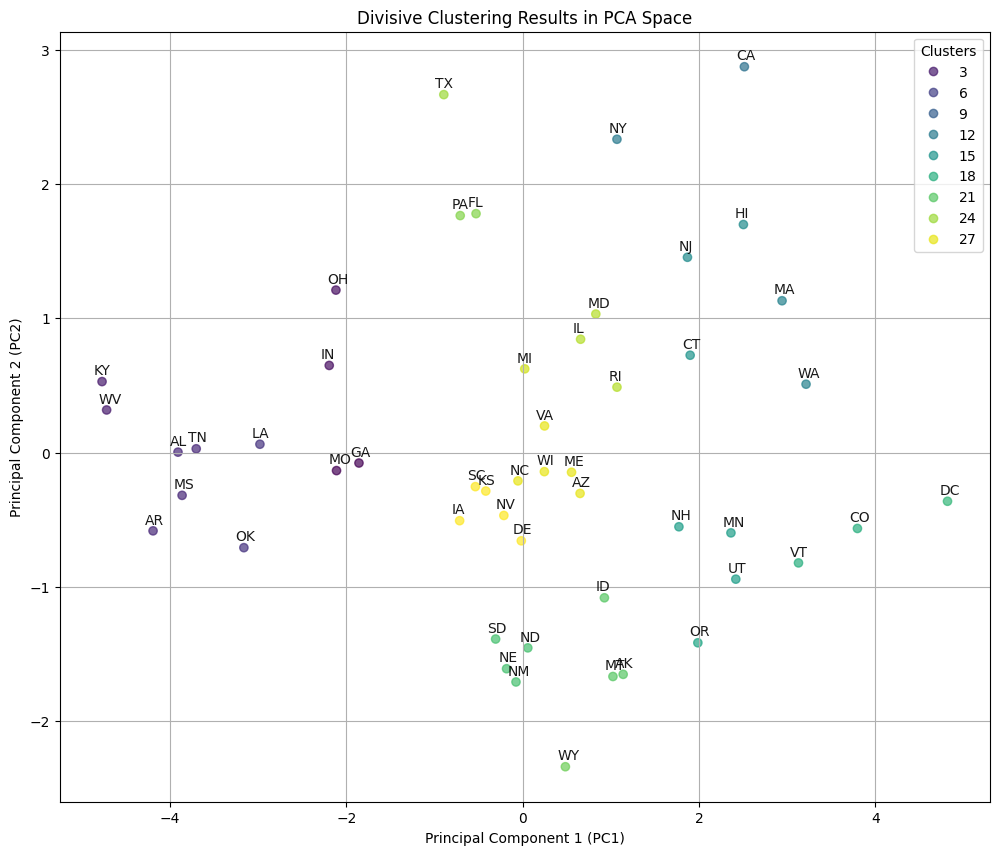

In [30]:
#Divisive Clustering #test if necessary or complicates analysis

from scipy.cluster.hierarchy import linkage, fcluster

df_pca['Initial_Cluster'] = KMeans(n_clusters=2, n_init=10, random_state=42).fit_predict(df_pca[['PC1', 'PC2']]) #2 is best

def divisive_clustering(data, initial_labels, threshold=0.5):
    clusters = {}
    unique_clusters = np.unique(initial_labels)
    for cluster in unique_clusters:
        cluster_data = data[initial_labels == cluster]
        if len(cluster_data) > 1:
            Z = linkage(cluster_data, method='ward')
            new_labels = fcluster(Z, t=threshold, criterion='distance')
            clusters[cluster] = new_labels

    return clusters

div_clusters = divisive_clustering(df_pca[['PC1', 'PC2']], df_pca['Initial_Cluster'], threshold=0.8) #hyperparameter tuning

for cluster, labels in div_clusters.items():
    df_pca.loc[df_pca['Initial_Cluster'] == cluster, 'Divisive_Cluster'] = labels + (cluster * 10)

num_clusters = df_pca['Divisive_Cluster'].nunique()
if num_clusters < 2:
    raise ValueError("< 2 clusters found, change threshold")

silhouette_avg = silhouette_score(df_pca[['PC1', 'PC2']], df_pca['Divisive_Cluster'])
print(f"Divisive Clustering Silhouette Score: {silhouette_avg}")

plt.figure(figsize=(12, 10))
scatter = plt.scatter(df_pca['PC1'], df_pca['PC2'], c=df_pca['Divisive_Cluster'], cmap='viridis', alpha=0.7)
plt.title('Divisive Clustering Results in PCA Space')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')

for i, state in enumerate(df_pca['State Abbr.']):
    plt.annotate(state, (df_pca['PC1'].iloc[i], df_pca['PC2'].iloc[i]), fontsize=10, alpha=0.9,
                 xytext=(-6, 5), textcoords='offset points')

plt.legend(*scatter.legend_elements(), title="Clusters", loc='upper right')
plt.grid()
plt.show()


In [31]:
num_clusters_divisive = df_pca['Divisive_Cluster'].nunique()
print(f"clusters formed {num_clusters_divisive}")

clusters formed 23


In [32]:
#testing out the clustering for the pre existing conditions not states

df_features = df_unsup.drop(columns=['State Abbr.'])
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_features), columns=df_features.columns)
df_scaled['State Abbr.'] = df_unsup['State Abbr.'].values


df_melted = pd.melt(df_scaled, id_vars=['State Abbr.'], var_name='Condition', value_name='Score')
df_pivoted = df_melted.pivot_table(index='Condition', columns='State Abbr.', values='Score')
df_pivoted


State Abbr.,AK,AL,AR,AZ,CA,CO,CT,DC,DE,FL,...,SD,TN,TX,UT,VA,VT,WA,WI,WV,WY
Condition,,,,,,,,,,,,,,,,,,,,,
AvgYearlyCovidRate,-0.774868,-0.168784,-0.400267,0.284873,4.201528,-0.187002,-0.455061,-0.732945,-0.729948,2.548495,...,-0.701119,0.286753,3.515632,-0.654424,-0.118373,-0.782855,-0.183345,-0.164501,-0.564496,-0.760906
BMI Category,-0.178407,1.341446,0.732940,-0.420804,-1.337115,-1.770458,-0.627514,-2.913164,0.874056,-0.266723,...,0.856608,0.914130,0.571984,-0.428502,0.234643,-1.756504,-0.586577,0.874902,1.457736,-0.087080
Cigarettes per Day,0.059918,-0.018017,1.531296,-0.095463,-1.809212,-1.094349,-0.260166,-2.581478,-0.121447,1.856175,...,-0.267544,1.650307,-0.382734,-2.531639,-0.290578,0.103766,-0.837972,0.289055,1.531158,0.467651
Data_Value,-0.822369,2.118641,1.790534,-0.750685,-0.636186,-1.306035,-1.268278,-0.983839,-0.916443,-0.743976,...,-0.037620,1.737713,0.601265,-0.770159,0.159979,-0.318348,-0.884207,-0.212379,0.890022,-0.204111
Drinks in Last 30 Days,0.560993,-2.003308,-1.169134,-0.140974,0.699506,1.176861,0.336755,1.063769,-0.302693,-0.392560,...,0.658675,-0.946452,0.540302,-2.584371,-0.396592,0.673656,0.024301,1.506911,-1.447399,-0.306707
Exercise in Past 30 Days,0.541723,-1.666695,-2.268827,-0.068246,0.997991,1.760302,0.330432,2.371211,0.030170,-0.614854,...,-0.313797,-1.300984,-0.721031,1.498210,0.498349,1.707375,1.596926,0.350450,-1.903931,-0.080138
General Health,0.369883,-1.793435,-2.224180,-0.376401,0.359852,1.341752,1.378004,2.173776,0.288055,-0.495489,...,0.409812,-1.463397,-0.923787,0.974437,0.252367,1.835910,0.526187,0.082547,-2.400289,0.802807
Hours of Sleeping,0.316238,-0.350441,0.292156,0.716825,-0.182403,0.494394,-0.727480,0.369614,-0.023808,0.513065,...,1.459882,-0.781333,-0.530971,-0.048997,0.311956,1.319179,0.961361,0.496649,-1.709980,1.714793
Shortness of Breath,-0.461917,-0.784514,-0.717353,0.211660,0.080148,0.261679,0.228520,-1.183827,-0.996956,0.668017,...,0.128200,-0.723254,1.111167,0.255497,0.192832,0.152648,4.443362,0.403307,-0.630803,-0.921927


In [33]:
df_reset = df_pivoted.reset_index()

scaler = StandardScaler()
data_scaled = scaler.fit_transform(df_reset.drop(columns='Condition'))

dbscan = DBSCAN(eps=0.5, min_samples=5)
clusters = dbscan.fit_predict(data_scaled)
df_reset['DBSCAN_Cluster'] = clusters

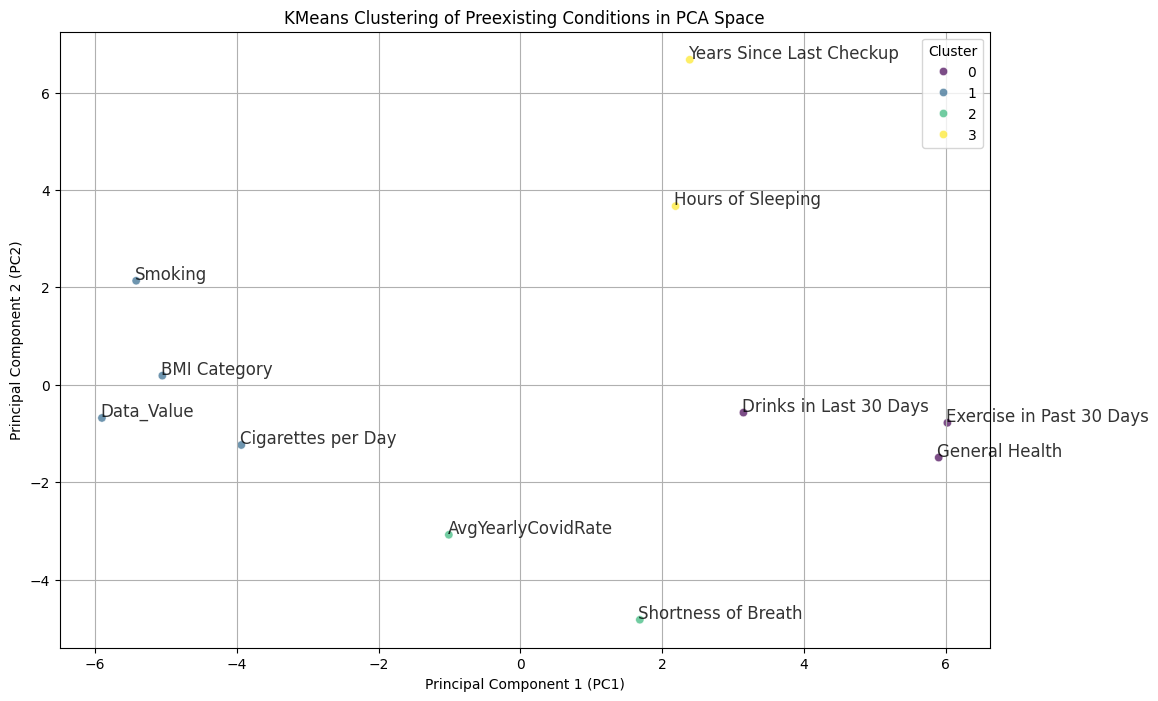

In [34]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(data_scaled)
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=42)
clusters = kmeans.fit_predict(pca_data)

df_pca_clusters = pd.DataFrame(pca_data, columns=['PC1', 'PC2'])
df_pca_clusters['Condition'] = df_reset['Condition']
df_pca_clusters['Cluster'] = clusters

plt.figure(figsize=(12, 8))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', palette='viridis', data=df_pca_clusters, alpha=0.7)

for i, condition in enumerate(df_pca_clusters['Condition']):
    plt.annotate(condition, (df_pca_clusters['PC1'].iloc[i], df_pca_clusters['PC2'].iloc[i]), fontsize=12, alpha=0.8,
                 xytext=(-1, 1), textcoords='offset points')

plt.title('KMeans Clustering of Preexisting Conditions in PCA Space')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.grid()
plt.legend(title='Cluster', loc='best')
plt.show()